#### Name: Venkatappareddy Manukonda

#### Course: MSCS-634 Advanced Big Data and Data Mining

#### Assignment: Classification Using KNN and RNN Algorithms

## Step 1: Load and Prepare the Dataset

This notebook uses the Wine dataset from sklearn to compare KNN and RNN classification. Before training the models, I explored the dataset, checked the class distribution, split the data into training and testing sets, and standardized the features for distance-based learning.

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

In [4]:
# Load the Wine dataset
wine = load_wine()

X = wine.data
y = wine.target

print("Dataset Shape:", X.shape)

Dataset Shape: (178, 13)


In [5]:
# Display feature names
print("Feature Names:\n")

for feature in wine.feature_names:
    print(feature)

Feature Names:

alcohol
malic_acid
ash
alcalinity_of_ash
magnesium
total_phenols
flavanoids
nonflavanoid_phenols
proanthocyanins
color_intensity
hue
od280/od315_of_diluted_wines
proline


In [6]:
# Examine class distribution
class_distribution = pd.Series(y).value_counts()

print("Class Distribution:")
print(class_distribution)

Class Distribution:
1    71
0    59
2    48
dtype: int64


In [7]:
# Create training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 142
Testing Samples: 36


In [8]:
# Standardize features for distance-based learning
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


### Dataset Summary

The dataset contains 178 wine samples with 13 chemical features and 3 target classes. The class distribution is reasonably balanced, which helps provide a fair evaluation of the models. Feature scaling was applied because both KNN and RNN rely on distance calculations when identifying neighbors.

## Step 2: Implement K-Nearest Neighbors (KNN)

In this step, I trained KNN models using different values of k to see how the number of neighbors affects classification accuracy.

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# K values to evaluate
k_values = [1, 5, 11, 15, 21]

knn_accuracies = []

for k in k_values:

    knn_model = KNeighborsClassifier(n_neighbors=k)

    knn_model.fit(X_train_scaled, y_train)

    predictions = knn_model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    knn_accuracies.append(accuracy)

    print(f"K = {k} | Accuracy = {accuracy:.4f}")

K = 1 | Accuracy = 0.9722
K = 5 | Accuracy = 0.9722
K = 11 | Accuracy = 1.0000
K = 15 | Accuracy = 1.0000
K = 21 | Accuracy = 1.0000


What I noticed from the KNN results was that accuracy improved as k increased. The model reached 100% accuracy at k = 11 and stayed there for larger values. This suggests that the wine classes are fairly well separated and that using a slightly larger neighborhood helped the model make more reliable predictions.

## Step 3: Implement Radius Neighbors (RNN)

In this step, I trained Radius Neighbors models using the radius values provided in the lab instructions to evaluate how different neighborhood sizes affect classification performance.

In [10]:
from sklearn.neighbors import RadiusNeighborsClassifier

radius_values = [350, 400, 450, 500, 550, 600]

rnn_accuracies = []

for radius in radius_values:

    rnn_model = RadiusNeighborsClassifier(
        radius=radius,
        outlier_label='most_frequent'
    )

    rnn_model.fit(X_train_scaled, y_train)

    predictions = rnn_model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    rnn_accuracies.append(accuracy)

    print(f"Radius = {radius} | Accuracy = {accuracy:.4f}")

Radius = 350 | Accuracy = 0.3889
Radius = 400 | Accuracy = 0.3889
Radius = 450 | Accuracy = 0.3889
Radius = 500 | Accuracy = 0.3889
Radius = 550 | Accuracy = 0.3889
Radius = 600 | Accuracy = 0.3889


The RNN results were surprising because every radius value produced exactly the same accuracy. At first, I expected the performance to change as the radius increased, but that did not happen. Looking at the scaled data helped explain why. The selected radius values were much larger than the feature range, so almost all training samples were treated as neighbors in every case.

## Step 4: Visualize and Compare Results

The following visualizations show how model accuracy changed across different parameter values and provide a clearer comparison between KNN and RNN performance.

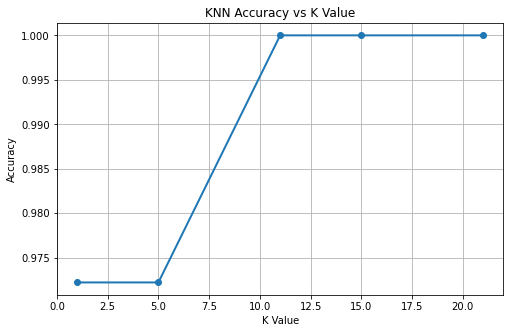

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    knn_accuracies,
    marker='o',
    linewidth=2
)

plt.title("KNN Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

The graph confirms the same pattern shown in the table. Accuracy increased quickly and then leveled off once k reached 11. After that point, increasing the neighborhood size did not improve performance further because the model was already classifying all test samples correctly.

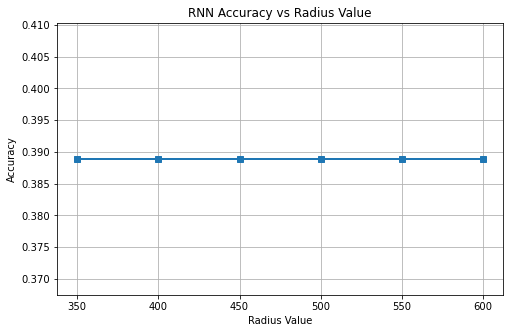

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    radius_values,
    rnn_accuracies,
    marker='s',
    linewidth=2
)

plt.title("RNN Accuracy vs Radius Value")
plt.xlabel("Radius Value")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

The flat line in the graph makes it easy to see that changing the radius had no impact on performance. Since the neighborhoods were already extremely large, increasing the radius further did not change how the model made its predictions.

## Comparison of KNN and RNN Performance

KNN clearly performed better than RNN in this experiment. The best KNN models achieved 100% accuracy, while RNN remained at 38.89% accuracy for all tested radius values.

The KNN results show that a fixed number of neighbors was effective for capturing the class patterns in the Wine dataset. In contrast, the radius values used in RNN were too large relative to the scaled feature space, causing the model to include too many neighbors during prediction.

Based on these results, KNN is the better choice for this dataset. RNN may be useful when the radius is carefully selected and data points are unevenly distributed, but KNN provided more accurate and consistent performance in this lab.